In [2]:
import pandas as pd
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt

     length  width
0       1.4    0.2
1       1.4    0.2
2       1.3    0.2
3       1.5    0.2
4       1.4    0.2
..      ...    ...
145     5.2    2.3
146     5.0    1.9
147     5.2    2.0
148     5.4    2.3
149     5.1    1.8

[150 rows x 2 columns]
     length  width  kmeans_labels  agg_labels
0       1.4    0.2              1           1
1       1.4    0.2              1           1
2       1.3    0.2              1           1
3       1.5    0.2              1           1
4       1.4    0.2              1           1
..      ...    ...            ...         ...
145     5.2    2.3              0           2
146     5.0    1.9              0           0
147     5.2    2.0              0           0
148     5.4    2.3              0           2
149     5.1    1.8              0           0

[150 rows x 4 columns]
kmeans_labels
0    100
1     50
Name: count, dtype: int64


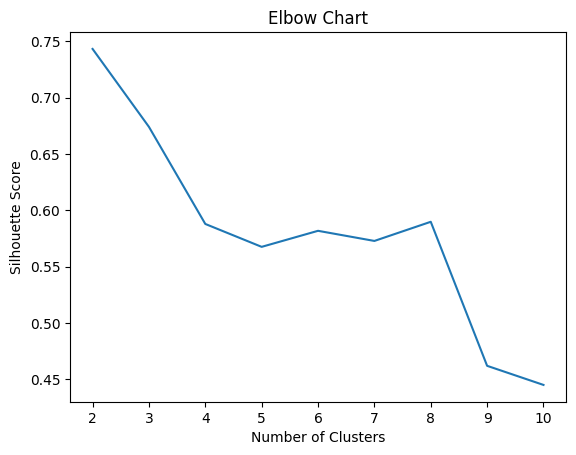

In [ ]:
df=pd.read_excel("M2.1 Data.xlsx")
print(df)

#standardise
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# k-means 2 cluster
from sklearn.cluster import KMeans
my_kmeans = KMeans(n_clusters=2)
my_kmeans.fit(X_scaled)
kmeans_labels = my_kmeans.labels_


#agllo cut at 3 clusters
from sklearn.cluster import AgglomerativeClustering
my_agg = AgglomerativeClustering(n_clusters=3)
my_agg.fit(X_scaled)
agg_labels = my_agg.labels_

#labeling
df_quiz = df.copy()
df_quiz['kmeans_labels'] = kmeans_labels
df_quiz['agg_labels'] = agg_labels

print(df_quiz)

#5 counts
print(df_quiz['kmeans_labels'].value_counts())

#6 elbow
from sklearn.metrics import silhouette_score

scores = []
for k in range(2, 11):
    my_kmeans = KMeans(n_clusters=k, random_state=42)
    my_kmeans.fit(X_scaled)
    score = silhouette_score(X_scaled, my_kmeans.labels_, metric='euclidean')
    scores.append(score)

plt.plot(range(2, 11), scores)
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Elbow Chart')
plt.show()



In [15]:
print(df_quiz.loc[[102, 103, 141, 142], ['kmeans_labels']])

print(df_quiz.loc[[2, 12, 67, 91], ['agg_labels']])

print(df_quiz['agg_labels'].value_counts())
print(df_quiz.loc[2, 'agg_labels'] == df_quiz.loc[12, 'agg_labels'])
print(df_quiz.loc[67, 'agg_labels'] == df_quiz.loc[91, 'agg_labels'])

     kmeans_labels
102              0
103              0
141              0
142              0
    agg_labels
2            1
12           1
67           0
91           0
agg_labels
0    75
1    50
2    25
Name: count, dtype: int64
True
True
